# CHOMP optimizer — tests & comparison with the WarmStartPlanner

CHOMP is a classical, learning-free trajectory optimizer. It minimizes collision + joint-limits +
smoothness via a covariant gradient update with fixed start/goal, and can be warm-started from a
model trajectory.

**Fair comparison.** CHOMP is built from the same `losses.py` terms the WarmStartPlanner is trained
on, so we point it at the **loaded model's own loss weights** (`train_loss`) rather than `chomp.py`'s
defaults. Otherwise the model would be competing against an optimizer chasing a different objective.
The step cap `eta` is *not* part of that loss — it is tuned separately, per init.

**Scoring** is independent of both: `TrajectoryEvaluator` judges every method on geometric
feasibility (`collision_free`, `n_collision_pts`, `min_clearance`) from the robot sphere *surface*
clearance, plus raw smoothness and path lengths. None of those depend on cost weights.

⚠️ **Never read a collision-free rate on its own, and always sanity-check the timings.**
* `mean_iters ≈ 1` means CHOMP stopped at its first check and passed the model output through
  unchanged — a no-op, not a refinement.
* A `max_smooth` far above the mean means CHOMP flung the arm around and stopped wherever it
  happened to be free — read `max_smooth` and `max_joint_viol` alongside the collision-free rate.

---
## Structure of this notebook

1. **Reusable pipeline** — all the logic lives in functions parametrized by a *pipeline* object
   (dataset + model + CHOMP settings + an output `name`). Define once, run for any model.
2. **Run A — `wsp_general_0907_v1`** on `dataset_general_0807_test` (the original test).
3. **Run B — `wsp_general_shapes_1707_v1`** on `dataset_general_shapes_1707_test` (new shapes model).

Each run writes its figures/CSVs/GIFs under a name derived from `pipe["name"]`, so the two runs
never overwrite each other's outputs.

In [1]:
# ---- Setup ----
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

SIMPLEARM_PATH = os.path.abspath("../external/SimpleArm/src")
if SIMPLEARM_PATH not in sys.path:
    sys.path.insert(0, SIMPLEARM_PATH)

from simplearm.robot import RobotInfo
from simplearm.geom import Obstacles, SquareGrid
from simplearm.viz import RobotViewer

from chomp import CHOMPOptimizer
from evaluation import TrajectoryEvaluator
import models
from visualization import save_viewer_as_gif

DEVICE = "cpu"
GRID_LENGTH = 2.5
torch.manual_seed(0)
np.random.seed(0)

# One colour per method. METHODS also fixes the row/bar order everywhere below (summary table,
# CSV, and every plot). Order: model -> CHOMP -> model+CHOMP, then the two extra-loss variants.
METHODS = ["Network", "CHOMP (cold)", "CHOMP (warm)",
           "CHOMP (cold, +extra)", "CHOMP (warm, +extra)"]
# The three "main" methods (no auxiliary exploration/spacing losses): for report figures that
# compare only Network vs. cold- vs. warm-started CHOMP.
MAIN_METHODS = ["Network", "CHOMP (cold)", "CHOMP (warm)"]
# Validated colourblind-safe categorical palette (fixed order == METHODS order), one hue per
# method. Assigned by identity, never cycled, so a method keeps its colour in every figure.
COLORS  = {"Network":                        "#2a78d6",   # blue
           "CHOMP (cold)":           "#eb6834",   # orange
           "CHOMP (warm)":                "#1baf7a",   # aqua
           "CHOMP (cold, +extra)":         "#eda100",   # yellow
           "CHOMP (warm, +extra)": "#e87ba4"}   # magenta

# ---- Publication style: clean, consistent figures for a report / paper ----
INK = dict(primary="#0b0b0b", secondary="#52514e", muted="#898781",
           grid="#e1e0d9", axis="#c3c2b7", surface="#ffffff")


def apply_paper_style():
    """Minimal, high-contrast Matplotlib defaults suited to print/LaTeX figures."""
    plt.rcParams.update({
        "figure.facecolor":  INK["surface"], "axes.facecolor": INK["surface"],
        "savefig.facecolor": INK["surface"],
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
        "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "semibold",
        "axes.labelsize": 11, "axes.labelcolor": INK["secondary"],
        "axes.edgecolor": INK["axis"], "axes.linewidth": 0.8,
        "axes.grid": True, "axes.axisbelow": True,
        "grid.color": INK["grid"], "grid.linewidth": 0.8,
        "xtick.color": INK["muted"], "ytick.color": INK["muted"],
        "xtick.labelcolor": INK["secondary"], "ytick.labelcolor": INK["secondary"],
        "text.color": INK["primary"],
        "legend.frameon": False, "legend.fontsize": 9,
        "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
        "svg.fonttype": "none", "pdf.fonttype": 42, "ps.fonttype": 42,
    })


def despine(ax, keep=("left", "bottom")):
    for side, sp in ax.spines.items():
        sp.set_visible(side in keep)


def save_figure(fig, results_dir, name):
    """Save a figure as vector PDF (for LaTeX) and 300-dpi PNG; return the path stub."""
    os.makedirs(results_dir, exist_ok=True)
    for ext in ("pdf", "png"):
        fig.savefig(f"{results_dir}/{name}.{ext}")
    return f"{results_dir}/{name}.{{pdf,png}}"


apply_paper_style()

## 1. Reusable pipeline

`build_pipeline` loads a dataset + model and constructs the two CHOMP optimizers straight from the
dataset metadata (same setup as `training.train`). Everything downstream takes the returned `pipe`
dict, so running a second model is just a second `build_pipeline(...)` call with different paths,
loss weights and an output `name`.

**CHOMP loss weights must match how the model was trained** (see `process_nvidia_1_sample.ipynb` /
`training_shapes.ipynb`): the model cannot look good merely because CHOMP was pointed at a different
objective. `train_loss` are those weights; `extra_losses` are the exploration + waypoint-spacing
terms the model was *also* trained on, used by the `+ extra losses` variants.

Deviation from training: training aggregates the collision cost with `max` (worst timestep only),
which carries gradient through a single waypoint and stalls a trajectory optimizer. Here CHOMP uses
`collision_agg="sum"` — the same per-step cost aggregated over all timesteps.

In [2]:
def build_pipeline(name, dataset_path, model_path, train_loss, extra_losses,
                   eta_scratch, eta_warm, T=50, C=10, device=DEVICE):
    """Load dataset + model and build the CHOMP optimizers. Returns a `pipe` dict consumed
    by every function below. `name` namespaces all outputs (resources/results_<name>/, GIFs)."""
    ds   = torch.load(dataset_path, weights_only=False)
    meta = ds["metadata"]

    # `chomp` optimizes exactly `train_loss`; `chomp_ex` adds the extra losses the model also saw.
    chomp    = CHOMPOptimizer.from_metadata(meta, T=T, device=device, **train_loss)
    chomp_ex = CHOMPOptimizer.from_metadata(meta, T=T, device=device, **train_loss, **extra_losses)

    # Scoring is optimizer-independent: geometric feasibility + smoothness, no cost weights.
    ev = TrajectoryEvaluator.from_metadata(meta, device=device)

    model = models.WarmStartPlanner(dof=meta["dof"], T=T, C=C,
                                    linklengths=meta["linklengths"]).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    results_dir = f"resources/results_{name}"
    pipe = dict(name=name, ds=ds, meta=meta, chomp=chomp, chomp_ex=chomp_ex, ev=ev,
                robot=chomp.robot, model=model, device=device, T=T, C=C,
                eta_scratch=eta_scratch, eta_warm=eta_warm, results_dir=results_dir)

    print(f"[{name}] optimizer HP:",
          dict(eps=chomp.eps, w_coll=chomp.w_coll, w_joints=chomp.w_joints,
               w_smooth=chomp.w_smooth, agg=chomp.collision_agg),
          "| eta scratch/warm:", (eta_scratch, eta_warm))
    print(f"[{name}] model: {model_path} | dataset N = {meta['N']} | outputs -> {results_dir}/")
    return pipe

In [3]:
def joint_violation(ev, traj):
    """Max amount (rad) by which any joint exceeds its limit over the trajectory (0 if within)."""
    tr = traj.to(ev.device).float()
    tr = tr.unsqueeze(0) if tr.ndim == 2 else tr
    over = torch.maximum((ev.q_min - tr).clamp(min=0), (tr - ev.q_max).clamp(min=0))
    return float(over.max().item())


def evaluate_sample(ev, tr, sdf_k):
    """Standard evaluation + an explicit joint-limit violation (rad) per trial."""
    e = ev.evaluate(tr, sdf_k)
    e["joint_violation"] = joint_violation(ev, tr)
    return e

### 1a. One sample: model vs. CHOMP-from-scratch vs. model→CHOMP

`find_colliding_sample` picks a sample where the model output collides but `model → CHOMP` fixes it
(the compelling before/after), falling back to the first colliding sample. `single_sample_report`
runs the three methods on it and returns the trajectories + a metrics table; `plot_cost_history` and
`show_before_after` render it. Pass `save_gifs=True` (and a `pipe`) to also export GIFs named after
the run.

In [4]:
def build_world(pipe, i):
    """Drawable world geometry for sample `i`, matching how the dataset was built.

    Blob datasets (shapes_*) store the true organic geometry in `voxels`; older circle
    datasets store only the seed `obstacles`. viz.RobotViewer accepts either a SquareGrid
    (voxel occupancy) or an Obstacles (circles), so the renderer is identical either way.
    Using the seed circles for a blob dataset would draw the wrong shapes."""
    ds, meta = pipe["ds"], pipe["meta"]
    if "voxels" in ds:
        vox = ds["voxels"][i, 0].numpy().astype(bool)
        return SquareGrid.from_zero_centered(
            limits=(-meta["grid_length"] / 2, meta["grid_length"] / 2),
            data=vox.T,
        )
    n_obs = ds["n_obstacles"][i].item()
    obs = ds["obstacles"][i, :n_obs]
    return Obstacles(x=obs[:, 0].numpy(), y=obs[:, 1].numpy(), r=obs[:, 2].numpy())


def find_colliding_sample(pipe, max_k=40, default=0):
    """First sample whose model output collides AND model->CHOMP repairs; fall back to the
    first colliding sample, then `default`. Deterministic, so both runs are reproducible."""
    ds, ev, model, chomp = pipe["ds"], pipe["ev"], pipe["model"], pipe["chomp"]
    fallback = None
    for k in range(min(max_k, pipe["meta"]["N"])):
        sk, qk, gk = ds["sdf"][k:k+1], ds["q_start"][k:k+1], ds["q_goal"][k:k+1]
        with torch.no_grad():
            wp_k = model(qk, gk, sk)
        if ev.evaluate(model.trajectory(wp_k), sk)["collision_free"]:
            continue
        if fallback is None:
            fallback = k
        tr_k = chomp.optimize(sk, qk, gk, init_waypoints=wp_k, max_iters=300, eta=pipe["eta_warm"])
        if ev.evaluate(tr_k, sk)["collision_free"]:
            return k
    return fallback if fallback is not None else default


def single_sample_report(pipe, i):
    """Run model / CHOMP-scratch / model+CHOMP on sample `i`; return trajectories, obstacles,
    the scratch cost history and a metrics DataFrame."""
    ds, ev, model, chomp, robot = pipe["ds"], pipe["ev"], pipe["model"], pipe["chomp"], pipe["robot"]
    sdf_i = ds["sdf"][i]
    qs_i  = ds["q_start"][i:i+1]
    qg_i  = ds["q_goal"][i:i+1]
    world = build_world(pipe, i)   # SquareGrid (blob voxels) or Obstacles (circles)

    # --- model --- (forward pass only)
    t0 = time.time()
    with torch.no_grad():
        wp_i       = model(qs_i, qg_i, sdf_i.unsqueeze(0))
        traj_model = model.trajectory(wp_i)
    t_model = time.time() - t0

    # --- CHOMP from scratch --- optimize until convergence (collision-free OR cost plateau).
    t0 = time.time()
    traj_scratch, hist = chomp.optimize(sdf_i, qs_i, qg_i, max_iters=500,
                                        eta=pipe["eta_scratch"], return_history=True)
    t_scratch = time.time() - t0

    # --- model + CHOMP --- warm-started refinement (includes the model forward pass above).
    t0 = time.time()
    traj_refined = chomp.optimize(sdf_i, qs_i, qg_i, init_waypoints=wp_i,
                                  max_iters=500, eta=pipe["eta_warm"])
    t_refined = t_model + (time.time() - t0)

    trajectories = {"Network": traj_model, "CHOMP (cold)": traj_scratch,
                    "CHOMP (warm)": traj_refined}
    times = {"Network": t_model, "CHOMP (cold)": t_scratch, "CHOMP (warm)": t_refined}

    rows = {}
    for name, tr in trajectories.items():
        e = ev.evaluate(tr, sdf_i)
        e["time_ms"] = times[name] * 1e3
        rows[name] = e
    df = pd.DataFrame(rows).T[["collision_free", "n_collision_pts", "min_clearance",
                               "smooth", "joint_path_length", "ee_path_length", "time_ms"]]
    return dict(i=i, trajectories=trajectories, world=world, hist=hist, df=df)


def plot_cost_history(report, pipe):
    """CHOMP-from-scratch optimization cost vs. iteration for the single-sample report."""
    fig, ax = plt.subplots(figsize=(8, 3))
    for key in ["total", "coll", "smooth"]:
        ax.plot([h[key] for h in report["hist"]], label=key)
    ax.set_xlabel("Iteration"); ax.set_ylabel("Optimizer cost"); ax.set_yscale("log")
    ax.legend(); ax.grid(True, which="both", alpha=0.3)
    ax.set_title(f"[{pipe['name']}] CHOMP cost vs. iteration (sample {report['i']})")
    plt.tight_layout(); plt.show()


def show_before_after(report, pipe, save_gifs=False, duration_ms=120):
    """Render model / CHOMP-from-scratch / model+CHOMP for the sample. GIFs (if requested) go
    to resources/<name>_<label>_sample_<i>.gif so the two runs never collide."""
    robot = pipe["robot"]
    for label, tr in report["trajectories"].items():
        print(label)
        viz = RobotViewer(tr.squeeze(0).cpu().numpy(), robot,
                          obstacles=report["world"], animate=True)
        viz.plot()
        if save_gifs:
            os.makedirs("resources", exist_ok=True)
            safe = label.replace(" ", "_").replace("+", "and").replace("(", "").replace(")", "").replace(",", "")
            save_viewer_as_gif(viz, f"resources/{pipe['name']}_{safe}_sample_{report['i']}.gif",
                               duration_ms=duration_ms)

### 1b. Speed & final-result comparison over many samples

`run_full_comparison` runs all five methods on the first `N_COMPARE` samples and returns
`(results, summary)`; the summary CSV is written to `pipe["results_dir"]`. Every CHOMP run uses the
model's own weights, so no method is handicapped by a different objective:

1. **Network** — forward pass only.
2. **CHOMP (cold)** — CHOMP on `train_loss` from a straight line.
3. **CHOMP (cold, +extra)** — same, plus the exploration + waypoint-spacing terms.
4. **CHOMP (warm)** — CHOMP refinement warm-started from the model output.
5. **CHOMP (warm, +extra)** — the same refinement with the extra losses enabled.

CHOMP runs until convergence (collision-free *or* cost plateau, capped at `max_iters`), so the
time/iteration numbers are meaningful. CHOMP is ~50-100x slower per sample, so keep `N_COMPARE`
modest. Watch `mean_iters` on the warm-started rows: ~1 means CHOMP passed the model output through
unchanged.

In [5]:
def summarise(ev, r):
    """Collapse one method's per-sample evals into the summary row."""
    evals, n = r["evals"], len(r["evals"])
    crashed = [not e["collision_free"] for e in evals]
    jviol   = [e["joint_violation"] for e in evals]
    smooth  = [e["smooth"] for e in evals]
    return {
        "crash_free":         f"{n - sum(crashed)}/{n}",
        "crash_free_rate":    1 - sum(crashed) / n,
        "crashed_trials":     sum(crashed),
        "mean_collisions":    np.mean([e["n_collision_pts"] for e in evals]),
        "max_collisions":     int(np.max([e["n_collision_pts"] for e in evals])),
        "mean_min_clear":     np.mean([e["min_clearance"] for e in evals]),
        "mean_smooth":        np.mean(smooth),
        "max_smooth":         np.max(smooth),
        "joint_limit_trials": int(sum(v > 1e-6 for v in jviol)),
        "max_joint_viol":     np.max(jviol),
        "mean_iters":         (np.mean(r["iters"]) if r["iters"] is not None else np.nan),
        "total_time_s":       np.sum(r["times"]),
        "mean_ms_per_sample": np.mean(r["times"]) * 1e3,
    }


def run_full_comparison(pipe, N_COMPARE=1000):
    """Run all five methods on the first N_COMPARE samples. Returns (results, summary_df) and
    writes summary.csv to pipe['results_dir']."""
    ds, ev, model = pipe["ds"], pipe["ev"], pipe["model"]
    chomp, chomp_ex = pipe["chomp"], pipe["chomp_ex"]
    idxs = list(range(N_COMPARE))
    sdf, qs, qg = ds["sdf"][idxs], ds["q_start"][idxs], ds["q_goal"][idxs]

    # Batched warmstart waypoints (reused by the model+CHOMP runs below).
    with torch.no_grad():
        wp = model(qs, qg, sdf)

    # --- Model --- time each sample individually so we get a per-sample distribution.
    model_evals, model_times = [], []
    for k in range(N_COMPARE):
        t0 = time.time()
        with torch.no_grad():
            wp_k = model(qs[k:k+1], qg[k:k+1], sdf[k:k+1])
            tr_k = model.trajectory(wp_k)
        model_times.append(time.time() - t0)
        model_evals.append(evaluate_sample(ev, tr_k, sdf[k:k+1]))

    def run_chomp(opt, use_warmstart, desc):
        """Optimize each sample until convergence; return (evals, per-sample times, iters).
        Each init gets its own best step cap (eta_scratch / eta_warm)."""
        eta = pipe["eta_warm"] if use_warmstart else pipe["eta_scratch"]
        evals, iters, times = [], [], []
        for k in tqdm(range(N_COMPARE), desc=desc):
            kw = dict(init_waypoints=wp[k:k+1]) if use_warmstart else {}
            t0 = time.time()
            tr, h = opt.optimize(sdf[k:k+1], qs[k:k+1], qg[k:k+1], max_iters=500, eta=eta,
                                 return_history=True, **kw)
            times.append(time.time() - t0)
            evals.append(evaluate_sample(ev, tr, sdf[k:k+1]))
            iters.append(len(h))
        return evals, times, iters

    scratch_evals,    scratch_times,    scratch_iters    = run_chomp(chomp,    False, "CHOMP scratch")
    scratch_ex_evals, scratch_ex_times, scratch_ex_iters = run_chomp(chomp_ex, False, "CHOMP scratch + extra")
    refine_evals,     refine_times0,    refine_iters     = run_chomp(chomp,    True,  "model+CHOMP")
    refine_ex_evals,  refine_ex_times0, refine_ex_iters  = run_chomp(chomp_ex, True,  "model+CHOMP + extra")
    # model+CHOMP per-sample time = model forward + CHOMP refinement.
    refine_times    = [model_times[k] + refine_times0[k]    for k in range(N_COMPARE)]
    refine_ex_times = [model_times[k] + refine_ex_times0[k] for k in range(N_COMPARE)]

    results = {
        "Network":                        dict(evals=model_evals,      iters=None,             times=model_times),
        "CHOMP (cold)":           dict(evals=scratch_evals,    iters=scratch_iters,    times=scratch_times),
        "CHOMP (cold, +extra)":         dict(evals=scratch_ex_evals, iters=scratch_ex_iters, times=scratch_ex_times),
        "CHOMP (warm)":                dict(evals=refine_evals,     iters=refine_iters,     times=refine_times),
        "CHOMP (warm, +extra)": dict(evals=refine_ex_evals,  iters=refine_ex_iters,  times=refine_ex_times),
    }

    summary = pd.DataFrame({m: summarise(ev, results[m]) for m in METHODS}).T
    os.makedirs(pipe["results_dir"], exist_ok=True)
    csv_path = os.path.join(pipe["results_dir"], "summary.csv")
    summary.to_csv(csv_path)
    print(f"[{pipe['name']}] saved summary to {csv_path}")
    return results, summary

In [6]:
def plot_bar_summary(results, pipe, methods=None, tag=""):
    """Headline bars — crash-free rate, computation time, iterations, joint violations and
    smoothness. Publication-styled: validated palette, direct labels, vector PDF + 300-dpi PNG
    per panel and a combined grid, saved to pipe['results_dir'].

    `methods` selects/orders which methods to show (default: all METHODS); pass MAIN_METHODS for
    the Network/cold/warm-only figures. `tag` is appended to every output filename so a subset can
    be saved next to the full set without overwriting (e.g. tag='_main3' -> crash_free_main3.pdf)."""
    apply_paper_style()
    methods = methods or METHODS
    results_dir = pipe["results_dir"]

    short = {"Network": "Network", "CHOMP (cold)": "CHOMP\n(cold)",
             "CHOMP (cold, +extra)": "CHOMP\n(cold,\n+extra)", "CHOMP (warm)": "CHOMP\n(warm)",
             "CHOMP (warm, +extra)": "CHOMP\n(warm,\n+extra)"}
    labels     = [short[m] for m in methods]
    bar_colors = [COLORS[m] for m in methods]
    x = np.arange(len(methods))
    n = len(results[methods[0]]["evals"])

    crash_free  = [1 - sum(not e["collision_free"] for e in results[m]["evals"]) / len(results[m]["evals"])
                   for m in methods]
    mean_ms     = [np.mean(results[m]["times"])   * 1e3 for m in methods]
    median_ms   = [np.median(results[m]["times"]) * 1e3 for m in methods]
    mean_iters  = [np.mean(results[m]["iters"]) if results[m]["iters"] is not None else 0 for m in methods]
    jviol_count = [sum(e["joint_violation"] > 1e-6 for e in results[m]["evals"]) for m in methods]
    jviol_pct   = [c / n * 100 for c in jviol_count]
    mean_smooth = [np.mean([e["smooth"] for e in results[m]["evals"]]) for m in methods]

    lblkw = dict(padding=2, fontsize=8, color=INK["secondary"])

    def _bars(ax, heights):
        b = ax.bar(x, heights, color=bar_colors, width=0.68,
                   edgecolor=INK["surface"], linewidth=0.8)
        ax.set_xticks(x); ax.set_xticklabels(labels)
        ax.grid(axis="y"); ax.grid(axis="x", visible=False); despine(ax)
        return b

    def panel_crash_free(ax):
        b = _bars(ax, [c * 100 for c in crash_free])
        ax.bar_label(b, fmt="%.1f%%", **lblkw)
        ax.set_ylabel("crash-free rate [%]"); ax.set_ylim(0, 108)
        ax.set_title("Crash-free rate")

    def panel_time(ax):
        from matplotlib.patches import Patch
        w = 0.34
        b1 = ax.bar(x - w / 2, mean_ms,   w, color=bar_colors, edgecolor=INK["surface"], linewidth=0.8)
        b2 = ax.bar(x + w / 2, median_ms, w, color=bar_colors, alpha=0.45,
                    edgecolor=INK["surface"], linewidth=0.8)
        ax.bar_label(b1, fmt="%.0f", **lblkw); ax.bar_label(b2, fmt="%.0f", **lblkw)
        ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(labels)
        ax.set_ylabel("time per sample [ms]")
        ax.grid(axis="y", which="both"); ax.grid(axis="x", visible=False); despine(ax)
        ax.legend(handles=[Patch(facecolor=INK["muted"], label="mean"),
                           Patch(facecolor=INK["muted"], alpha=0.45, label="median")],
                  loc="upper left")
        ax.set_title("Computation time")

    def panel_iters(ax):
        b = _bars(ax, mean_iters)
        ax.bar_label(b, fmt="%.1f", **lblkw)
        ax.set_ylabel("mean iterations"); ax.set_title("Iterations to convergence")

    def panel_joint_viol(ax):
        b = _bars(ax, jviol_pct)
        ax.bar_label(b, labels=[f"{p:.1f}%" for p in jviol_pct], **lblkw)
        ax.set_ylabel("trials with violation [%]"); ax.set_title("Joint-limit violations")

    def panel_smooth(ax):
        b = _bars(ax, mean_smooth)
        ax.bar_label(b, fmt="%.3f", **lblkw)
        ax.set_ylabel("mean smoothness cost"); ax.set_title("Smoothness (lower = smoother)")

    PANELS = [
        ("crash_free",       panel_crash_free),
        ("computation_time", panel_time),
        ("iterations",       panel_iters),
        ("joint_violations", panel_joint_viol),
        ("smoothness",       panel_smooth),
    ]

    # Standalone panels: each as its own PDF + PNG, so any single one drops into the paper.
    for name, draw in PANELS:
        fig_i, ax_i = plt.subplots(figsize=(5.2, 3.6))
        draw(ax_i)
        ax_i.set_title(f"{ax_i.get_title()}  (N = {n} samples)")   # sample count always in title
        fig_i.tight_layout()
        save_figure(fig_i, results_dir, name + tag)
        plt.close(fig_i)

    # Combined 2x3 overview (last panel holds a shared legend).
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
    flat = axes.flatten()
    for (name, draw), ax in zip(PANELS, flat):
        draw(ax)
    from matplotlib.patches import Patch
    flat[-1].axis("off")
    flat[-1].legend(handles=[Patch(facecolor=COLORS[m], label=m) for m in methods],
                    loc="center", fontsize=11, title="method", title_fontsize=12)
    fig.suptitle(f"CHOMP vs. WarmStartPlanner  (N = {n} samples)",
                 fontsize=15, color=INK["primary"])
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    save_figure(fig, results_dir, "summary_grid" + tag)
    label = f" [{tag.lstrip('_')}]" if tag else ""
    print(f"[{pipe['name']}] saved {len(PANELS)} panels + summary_grid (PDF+PNG){label} to {results_dir}/")
    plt.show()

In [7]:
def plot_distributions(results, pipe, methods=None, tag=""):
    """Per-method metric distributions as clean step histograms (far more legible than several
    overlapping filled bars): feasibility, collisions, smoothness, joint violations, time. Saved as
    a single PDF + PNG to pipe['results_dir']; a shared legend sits in the 6th panel.

    `methods`/`tag` behave as in plot_bar_summary (pass MAIN_METHODS + tag='_main3' for the
    three-method-only figure)."""
    apply_paper_style()
    methods = methods or METHODS
    results_dir = pipe["results_dir"]

    def vals(m, key):
        return [e[key] for e in results[m]["evals"]]

    n = len(results[methods[0]]["evals"])

    def step_hist(ax, key, bins):
        for m in methods:
            ax.hist(vals(m, key), bins=bins, histtype="step", linewidth=1.8, color=COLORS[m])
        despine(ax); ax.grid(axis="y")

    fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))

    # (1) Feasibility — collision-free vs. crashed trials, grouped bars.
    ax = axes[0, 0]
    w  = 0.8 / len(methods)
    xb = np.arange(2)
    for j, m in enumerate(methods):
        free = sum(e["collision_free"] for e in results[m]["evals"])
        off  = (j - (len(methods) - 1) / 2) * w
        ax.bar(xb + off, [free, n - free], w, color=COLORS[m],
               edgecolor=INK["surface"], linewidth=0.6)
    ax.set_xticks(xb); ax.set_xticklabels(["collision-free", "crashed ≥ 1×"])
    ax.set_ylabel("number of trials"); ax.set_title("Feasibility")
    despine(ax); ax.grid(axis="y"); ax.grid(axis="x", visible=False)

    # (2) Collisions per trial.
    ax = axes[0, 1]
    allc = [v for m in methods for v in vals(m, "n_collision_pts")]
    bins = np.histogram_bin_edges(allc, bins=12) if max(allc) > 0 else np.arange(-0.5, 2.5)
    step_hist(ax, "n_collision_pts", bins)
    ax.set_xlabel("collision points per trial"); ax.set_ylabel("# trials")
    ax.set_title("Collisions per trial")

    # (3) Smoothness (lower = smoother).
    ax = axes[0, 2]
    bins = np.histogram_bin_edges([v for m in methods for v in vals(m, "smooth")], bins=14)
    step_hist(ax, "smooth", bins)
    ax.set_xlabel("smoothness cost (lower = smoother)"); ax.set_ylabel("# trials")
    ax.set_title("Smoothness")

    # (4) Joint-limit violations.
    ax = axes[1, 0]
    allj = [v for m in methods for v in vals(m, "joint_violation")]
    if max(allj) <= 1e-6:
        ax.text(0.5, 0.5, "no joint-limit violations\nin any method", ha="center", va="center",
                transform=ax.transAxes, color=INK["secondary"])
        ax.set_xticks([]); ax.set_yticks([]); despine(ax, keep=())
    else:
        bins = np.histogram_bin_edges(allj, bins=12)
        step_hist(ax, "joint_violation", bins)
        ax.set_xlabel("max joint-limit overshoot [rad]"); ax.set_ylabel("# trials")
    ax.set_title("Joint-limit violations")

    # (5) Computation time (log x: Network ~ms, CHOMP ~s).
    ax = axes[1, 1]
    allt = [t for m in methods for t in results[m]["times"]]
    bins = np.logspace(np.log10(min(allt)), np.log10(max(allt)), 18)
    for m in methods:
        ax.hist(results[m]["times"], bins=bins, histtype="step", linewidth=1.8, color=COLORS[m])
    ax.set_xscale("log"); despine(ax); ax.grid(axis="y", which="both")
    ax.set_xlabel("computation time per sample [s]"); ax.set_ylabel("# trials")
    ax.set_title("Computation time")

    # (6) Shared legend (identity is never colour-alone).
    ax = axes[1, 2]; ax.axis("off")
    from matplotlib.lines import Line2D
    ax.legend(handles=[Line2D([0], [0], color=COLORS[m], lw=2.4, label=m) for m in methods],
              loc="center", fontsize=11, title="method", title_fontsize=12)

    fig.suptitle(f"Metric distributions  (N = {n} samples)",
                 fontsize=15, color=INK["primary"])
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    save_figure(fig, results_dir, "distributions" + tag)
    label = f" [{tag.lstrip('_')}]" if tag else ""
    print(f"[{pipe['name']}] saved distributions (PDF+PNG){label} to {results_dir}/")
    plt.show()

## 2. Run A — `wsp_general_0907_v1` (original test)

Loss weights from the `wsp_general_0907_v1` run in `process_nvidia_1_sample.ipynb`
(`w_coll=350`, `eps=0.15`). `eta` tuned separately: scratch 300, warm 1500.

In [ ]:
orig = build_pipeline(
    name         = "general_0907_v1",
    dataset_path = "data/dataset_general_0807_test.pt",
    model_path   = "models/wsp_general_0907_v1.pt",
    train_loss   = dict(eps=0.15, w_coll=350.0, w_joints=1.0, w_smooth=1.0, collision_agg="sum"),
    extra_losses = dict(w_explore=5.0, w_spacing=2.0, explore_threshold=0.5),
    eta_scratch  = 300,
    eta_warm     = 1500,
)

In [ ]:
# --- single sample ---
i_orig = find_colliding_sample(orig)
print(f"Using sample {i_orig} (model output collides)")
report_orig = single_sample_report(orig, i_orig)
report_orig["df"]

In [ ]:
plot_cost_history(report_orig, orig)

In [ ]:
show_before_after(report_orig, orig, save_gifs=False)

In [ ]:
# --- full comparison (CHOMP is slow: keep N_COMPARE modest) ---
results_orig, summary_orig = run_full_comparison(orig, N_COMPARE=1000)
summary_orig.round(3)

In [ ]:
plot_bar_summary(results_orig, orig)                                       # all 5 methods
plot_bar_summary(results_orig, orig, methods=MAIN_METHODS, tag="_main3")   # Network / cold / warm only

In [ ]:
plot_distributions(results_orig, orig)
plot_distributions(results_orig, orig, methods=MAIN_METHODS, tag="_main3")

## 3. Run B — `wsp_general_shapes_1707_v1` (new shapes model)

Same analysis, **different model + dataset + output name**. The CHOMP loss weights match how this
model was trained in `training_shapes.ipynb` — `w_coll=400`, `eps=0.15`, and the extra losses
`w_explore=5`, `w_spacing=2`, `explore_threshold=0.5` (differs from Run A only in `w_coll`,
350 → 400). `eta` (a step size, not a loss weight) is kept at scratch 300 / warm 1500.

All outputs land under `resources/results_general_shapes_1707_v1/` and GIFs are prefixed
`general_shapes_1707_v1_…`, so nothing overwrites Run A.

In [8]:
shapes = build_pipeline(
    name         = "general_shapes_1707_v1",
    dataset_path = "data/dataset_general_shapes_1707_test.pt",
    model_path   = "models/wsp_general_shapes_1707_v1.pt",
    train_loss   = dict(eps=0.15, w_coll=400.0, w_joints=1.0, w_smooth=1.0, collision_agg="sum"),
    extra_losses = dict(w_explore=5.0, w_spacing=2.0, explore_threshold=0.5),
    eta_scratch  = 300,
    eta_warm     = 1500,
)

[general_shapes_1707_v1] optimizer HP: {'eps': 0.15, 'w_coll': 400.0, 'w_joints': 1.0, 'w_smooth': 1.0, 'agg': 'sum'} | eta scratch/warm: (300, 1500)
[general_shapes_1707_v1] model: models/wsp_general_shapes_1707_v1.pt | dataset N = 1500 | outputs -> resources/results_general_shapes_1707_v1/


In [9]:
# --- single sample ---
i_shapes = find_colliding_sample(shapes)
print(f"Using sample {i_shapes} (model output collides)")
report_shapes = single_sample_report(shapes, i_shapes)
report_shapes["df"]

Using sample 13 (model output collides)


,collision_free,n_collision_pts,min_clearance,smooth,joint_path_length,ee_path_length,time_ms
model,False,26,-0.153554,0.15427,3.1669,1.304552,6.709099
CHOMP from scratch,False,8,-0.190426,2.015062,10.572217,6.024981,545.8529
model + CHOMP,True,0,0.001021,0.553881,6.090475,1.612019,412.469149


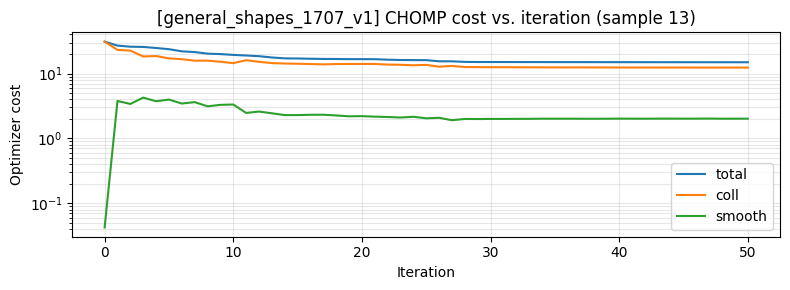

In [10]:
plot_cost_history(report_shapes, shapes)

In [11]:
show_before_after(report_shapes, shapes, save_gifs=False)

model
⠼ Plotting robot... (0:00:01.13) 

CHOMP from scratch               
⠴ Plotting robot... (0:00:01.05) 

model + CHOMP                    
⠦ Plotting robot... (0:00:00.91) 

In [14]:
# --- full comparison (CHOMP is slow: keep N_COMPARE modest) ---
results_shapes, summary_shapes = run_full_comparison(shapes, N_COMPARE=100)
summary_shapes.round(3)

CHOMP scratch:   0%|          | 0/100 [00:00<?, ?it/s]

CHOMP scratch + extra:   0%|          | 0/100 [00:00<?, ?it/s]

model+CHOMP:   0%|          | 0/100 [00:00<?, ?it/s]

model+CHOMP + extra:   0%|          | 0/100 [00:00<?, ?it/s]

[general_shapes_1707_v1] saved summary to resources/results_general_shapes_1707_v1/summary.csv


,crash_free,crash_free_rate,crashed_trials,mean_collisions,max_collisions,mean_min_clear,mean_smooth,max_smooth,joint_limit_trials,max_joint_viol,mean_iters,total_time_s,mean_ms_per_sample
model,70/100,0.7,30,4.66,84,0.013331,0.854646,1.757379,16,0.260281,NaN,0.803657,8.036566
CHOMP from scratch,63/100,0.63,37,4.11,30,-0.031016,1.069572,5.801978,28,2.15334,20.98,22.594038,225.940378
model + CHOMP,93/100,0.93,7,0.78,18,0.031109,0.857545,2.642013,7,1.046024,5.43,6.204979,62.049794
CHOMP + extra losses,62/100,0.62,38,4.29,26,-0.032306,2.603134,31.415577,44,12.677512,24.37,47.255785,472.55785
model + CHOMP + extra losses,93/100,0.93,7,0.82,18,0.030888,0.844223,1.706858,7,1.038592,5.46,10.681642,106.816423


[general_shapes_1707_v1] saved 5 panels + summary_grid.png to resources/results_general_shapes_1707_v1/


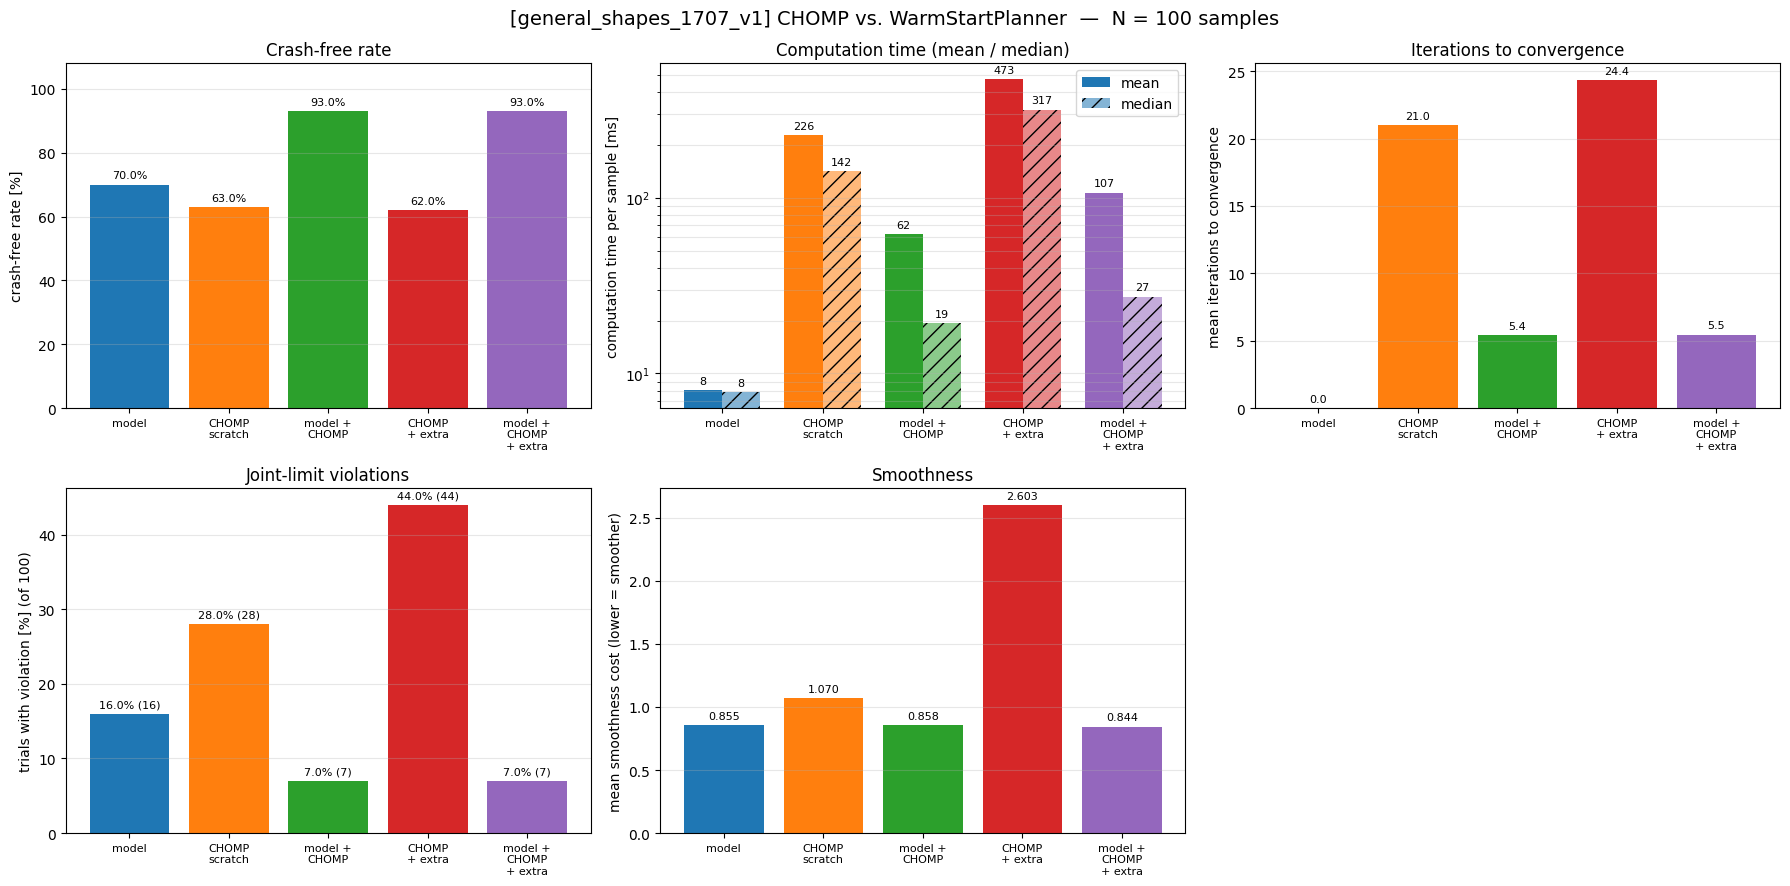

In [15]:
plot_bar_summary(results_shapes, shapes)                                       # all 5 methods
plot_bar_summary(results_shapes, shapes, methods=MAIN_METHODS, tag="_main3")   # Network / cold / warm only

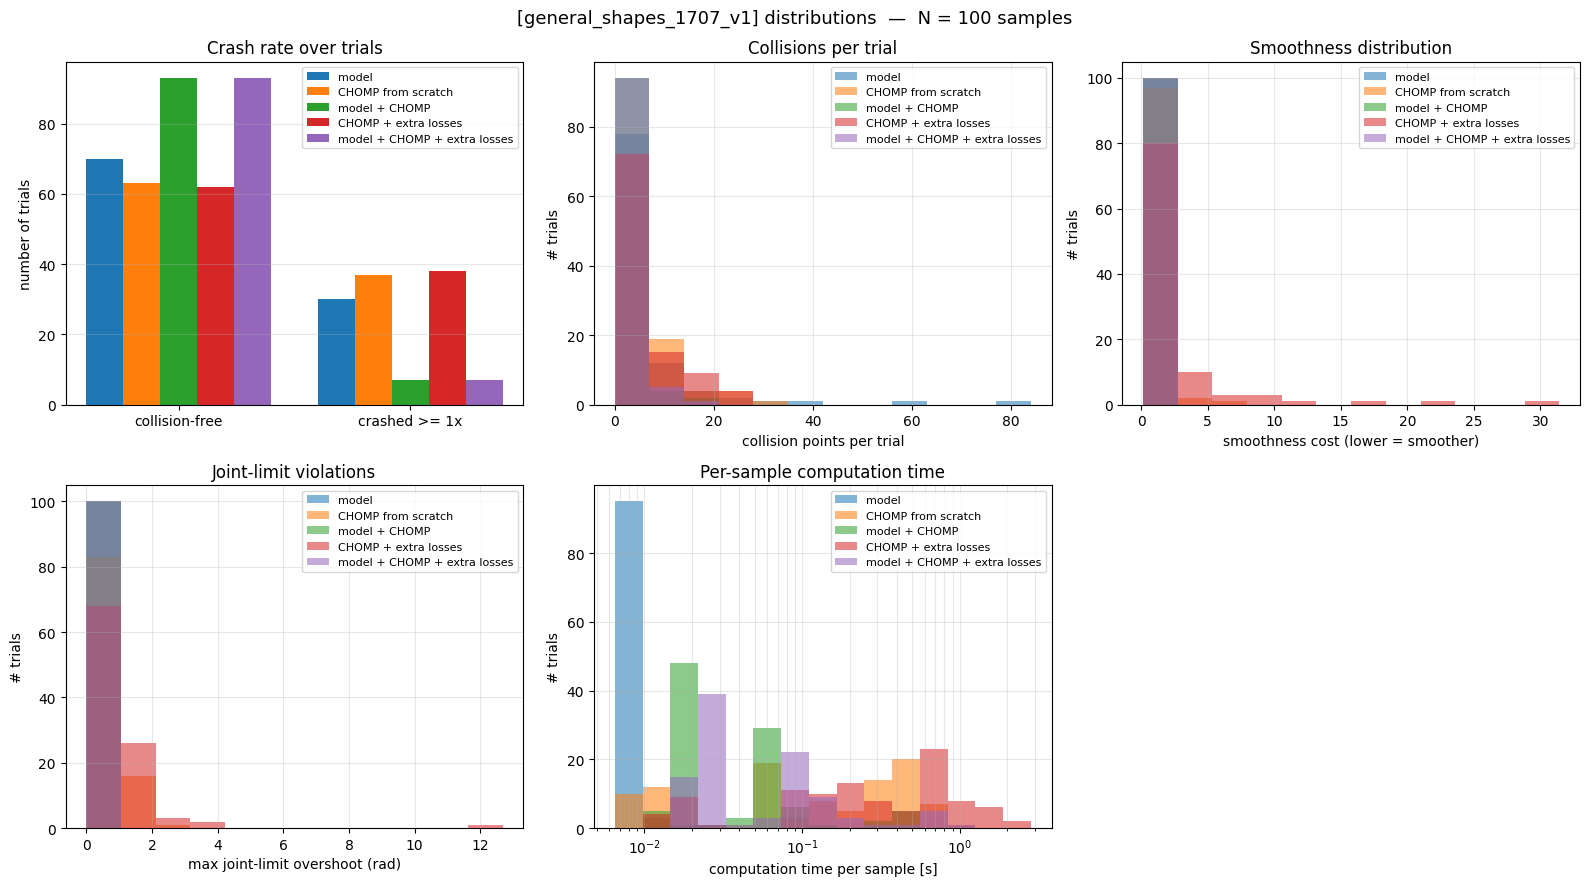

In [16]:
plot_distributions(results_shapes, shapes)
plot_distributions(results_shapes, shapes, methods=MAIN_METHODS, tag="_main3")